In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def load_csv(csv_file):
    data = np.genfromtxt(csv_file, delimiter=",", skip_header=1)
    t = np.asarray(data[:, 0], dtype=np.float32)
    ch1 = np.asarray(data[:, 1], dtype=np.float32)
    # ch2 = np.asarray(data[:, 2], dtype=np.float32)
    return t, ch1

def compute_fft(t, y):
    dt = t[1] - t[0]
    N = len(y)
    Y = np.fft.fft(y)
    f = np.fft.fftfreq(N, d=dt)

    Y = np.fft.fftshift(Y)
    f = np.fft.fftshift(f)

    return f, np.abs(Y / len(y))

def get_peak_freq(t, y):
    # mask = t > 0
    # f, Y = compute_fft(t[mask], y[mask])
    f, Y = compute_fft(t, y)
    Y = np.abs(Y)
    return np.abs(f[np.argmax(Y)]) / 1e6

In [29]:
# answers = [ 5.373296, 38.923847 33.074005 22.505043 22.217746 43.071298  5.211336
#  35.171034 10.872007  5.61469 ]

def make_t(sample_rate_returned, num_of_points):

    sample_rate = sample_rate_returned / 4
    dt = (1 / sample_rate)
    t = np.arange(-num_of_points / 2, num_of_points / 2, 1) * dt 
    return t

t = make_t(2.5e9, 10000)

wave = np.load(f"./data/waveforms.npy")


for i in range(100):
    ch1 = wave[i]
    freq = get_peak_freq(t, ch1)
    print(freq)
    # if (i % 5 == 1):
    #     print(freq - 5.373296 > 1)
    #     print(freq)
    # if (i % 5 == 2):
    #     print(freq - 38.923847 > 1)
    # if (i % 5 == 3):
    #     print(freq - 33.074005 > 1)
    # if (i % 5 == 4):
    #     print(freq - 22.505043 > 1)
    # if (i % 5 == 0):
    #     print(freq - 22.217746 > 1)

5.624999999999577
5.374999999999597
38.93749999999708
33.06249999999752
22.49999999999831
22.187499999998334
43.06249999999677
5.187499999999611
35.18749999999736
10.874999999999185
5.624999999999577
5.374999999999597
38.93749999999708
33.06249999999752
22.49999999999831
22.187499999998334
43.06249999999677
5.187499999999611
35.18749999999736
10.874999999999185
5.624999999999577
5.374999999999597
38.93749999999708
33.06249999999752
22.49999999999831
22.187499999998334
43.06249999999677
5.187499999999611
35.18749999999736
10.874999999999185
5.624999999999577
5.374999999999597
38.93749999999708
33.06249999999752
22.49999999999831
22.187499999998334
43.06249999999677
5.187499999999611
35.18749999999736
10.874999999999185
5.624999999999577
5.374999999999597
38.93749999999708
33.06249999999752
22.49999999999831
22.187499999998334
43.06249999999677
5.187499999999611
35.18749999999736
10.874999999999185
5.624999999999577
5.374999999999597
38.93749999999708
33.06249999999752
22.49999999999831


38.93749999999708


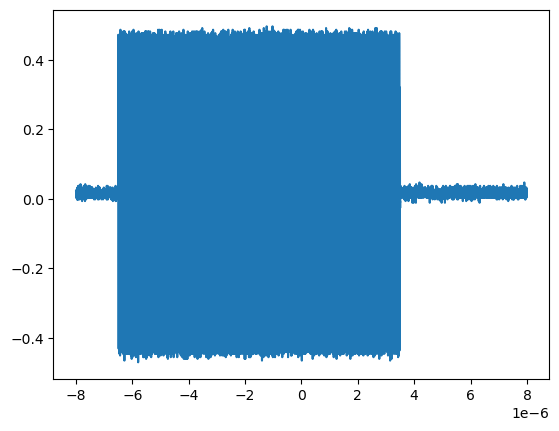

In [30]:
ch1 = np.load(f"./data/raw.npy")
freq = get_peak_freq(t, ch1)
fig, ax = plt.subplots()
ax.plot(t, ch1)
print(freq)


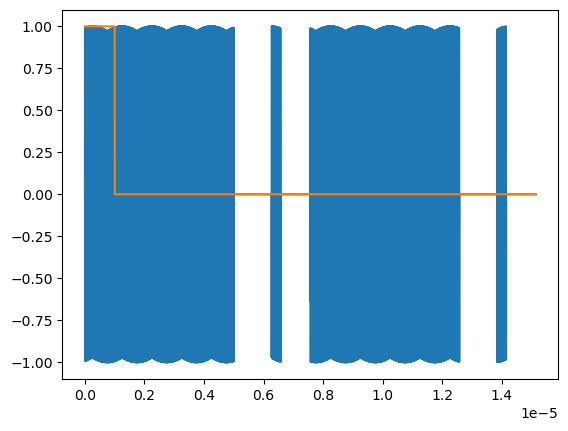

In [7]:
def load_csv_two_channels(csv_file):
    data = np.genfromtxt(csv_file, delimiter=",", skip_header=1)
    t = np.asarray(data[:, 0], dtype=np.float32)
    ch1 = np.asarray(data[:, 1], dtype=np.float32)
    ch2 = np.asarray(data[:, 2], dtype=np.float32)
    return t, ch1, ch2

t, ch1, ch2 = load_csv_two_channels("./waveforms/test.csv")
fig, ax = plt.subplots()
ax.plot(t, ch1)
ax.plot(t, ch2)
# ax.set_xlim(0, 1e-5)